In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [2]:
PROJECT_DIR = Path.cwd().resolve().parent

PROCESSED_DIR = (
    PROJECT_DIR /
    'data' /
    'processed'
)

PROCESSED_DIR

WindowsPath('D:/@SKIRPSI AZHAR/code/data/processed')

In [3]:
master_df = pd.read_parquet(
    PROCESSED_DIR /
    'master_dataset.parquet'
)

In [4]:
master_df.shape

(30735648, 34)

In [5]:
master_df.head()

,Household_ID,AffectsTimePoint,Group_x,Timestamp,kWh_received_Total,kWh_received_HeatPump,kWh_received_Other,Group_y,Weather_ID,Installation_HasPVSystem,Protocols_Available,Protocols_HasMultipleVisits,Protocols_ReportIDs,MetaData_Available,SmartMeterData_Available_15min,SmartMeterData_Available_Daily,SmartMeterData_Available_Monthly,Survey_Building_Type,Survey_Building_LivingArea,Survey_Building_Residents,Survey_HeatPump_Installation_Type,Survey_HeatDistribution_System_FloorHeating,Survey_HeatDistribution_System_Radiator,Survey_DHW_Production_ByHeatPump,Survey_DHW_Production_ByElectricWaterHeater,Survey_DHW_Production_BySolar,Survey_Installation_HasDryer,Survey_Installation_HasFreezer,Survey_Installation_HasElectricVehicle,Timestamp_hour,Temperature_avg_hourly,Humidity_avg_hourly,Precipitation_total_hourly,WindSpeed_hourly
0,10266,unknown,control,2021-01-17 00:00:00+00:00,0.0,NaN,NaN,control,z6I,None,False,False,NaN,True,True,True,True,house,240.0,2.0,air-source,False,True,True,None,None,True,True,True,2021-01-17 00:00:00+00:00,-3.2,92.4,0.6,1.4
1,10266,unknown,control,2021-01-17 00:15:00+00:00,0.0,NaN,NaN,control,z6I,None,False,False,NaN,True,True,True,True,house,240.0,2.0,air-source,False,True,True,None,None,True,True,True,2021-01-17 00:00:00+00:00,-3.2,92.4,0.6,1.4
2,10266,unknown,control,2021-01-17 00:30:00+00:00,0.0,NaN,NaN,control,z6I,None,False,False,NaN,True,True,True,True,house,240.0,2.0,air-source,False,True,True,None,None,True,True,True,2021-01-17 00:00:00+00:00,-3.2,92.4,0.6,1.4
3,10266,unknown,control,2021-01-17 00:45:00+00:00,0.0,NaN,NaN,control,z6I,None,False,False,NaN,True,True,True,True,house,240.0,2.0,air-source,False,True,True,None,None,True,True,True,2021-01-17 00:00:00+00:00,-3.2,92.4,0.6,1.4
4,10266,unknown,control,2021-01-17 01:00:00+00:00,0.0,NaN,NaN,control,z6I,None,False,False,NaN,True,True,True,True,house,240.0,2.0,air-source,False,True,True,None,None,True,True,True,2021-01-17 01:00:00+00:00,-3.2,92.3,0.5,1.1


In [6]:
master_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30735648 entries, 0 to 30735647
Data columns (total 34 columns):
 #   Column                                       Dtype              
---  ------                                       -----              
 0   Household_ID                                 int64              
 1   AffectsTimePoint                             str                
 2   Group_x                                      str                
 3   Timestamp                                    datetime64[us, UTC]
 4   kWh_received_Total                           float64            
 5   kWh_received_HeatPump                        float64            
 6   kWh_received_Other                           float64            
 7   Group_y                                      str                
 8   Weather_ID                                   str                
 9   Installation_HasPVSystem                     object             
 10  Protocols_Available                          bool  

In [7]:
memory_mb = (
    master_df
    .memory_usage(deep=True)
    .sum()
    / 1024**2
)

print(
    f"Memory Usage : {memory_mb:.2f} MB"
)

Memory Usage : 14384.00 MB


# Data Type Optimization

In [8]:
memory_before = (
    master_df.memory_usage(deep=True)
    .sum()
    / 1024**2
)

print(f"Before : {memory_before:.2f} MB")

Before : 14384.00 MB


In [9]:
master_df.dtypes.value_counts()

float64                9
object                 9
str                    7
bool                   6
datetime64[us, UTC]    2
int64                  1
Name: count, dtype: int64

In [10]:
int_cols = master_df.select_dtypes(
    include=['int64']
).columns

master_df[int_cols] = (
    master_df[int_cols]
    .astype('int32')
)

In [11]:
float_cols = master_df.select_dtypes(
    include=['float64']
).columns

master_df[float_cols] = (
    master_df[float_cols]
    .astype('float32')
)

In [12]:
str_cols = master_df.select_dtypes(
    include=['object', 'string']
).columns

str_cols

Index(['AffectsTimePoint', 'Group_x', 'Group_y', 'Weather_ID',
       'Installation_HasPVSystem', 'Protocols_ReportIDs',
       'Survey_Building_Type', 'Survey_HeatPump_Installation_Type',
       'Survey_HeatDistribution_System_FloorHeating',
       'Survey_HeatDistribution_System_Radiator',
       'Survey_DHW_Production_ByHeatPump',
       'Survey_DHW_Production_ByElectricWaterHeater',
       'Survey_DHW_Production_BySolar', 'Survey_Installation_HasDryer',
       'Survey_Installation_HasFreezer',
       'Survey_Installation_HasElectricVehicle'],
      dtype='str')

In [13]:
for col in str_cols:
    master_df[col] = (
        master_df[col]
        .astype('category')
    )

In [14]:
master_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30735648 entries, 0 to 30735647
Data columns (total 34 columns):
 #   Column                                       Dtype              
---  ------                                       -----              
 0   Household_ID                                 int32              
 1   AffectsTimePoint                             category           
 2   Group_x                                      category           
 3   Timestamp                                    datetime64[us, UTC]
 4   kWh_received_Total                           float32            
 5   kWh_received_HeatPump                        float32            
 6   kWh_received_Other                           float32            
 7   Group_y                                      category           
 8   Weather_ID                                   category           
 9   Installation_HasPVSystem                     category           
 10  Protocols_Available                          bool  

In [15]:
memory_after = (
    master_df.memory_usage(deep=True)
    .sum()
    / 1024**2
)

print(f"After : {memory_after:.2f} MB")

After : 2286.32 MB


In [16]:
reduction = (
    (memory_before - memory_after)
    / memory_before
) * 100

print(
    f"Memory Reduction : {reduction:.2f}%"
)

Memory Reduction : 84.11%


# Drop Unnecessary Features

In [17]:
master_df.columns.tolist()

['Household_ID',
 'AffectsTimePoint',
 'Group_x',
 'Timestamp',
 'kWh_received_Total',
 'kWh_received_HeatPump',
 'kWh_received_Other',
 'Group_y',
 'Weather_ID',
 'Installation_HasPVSystem',
 'Protocols_Available',
 'Protocols_HasMultipleVisits',
 'Protocols_ReportIDs',
 'MetaData_Available',
 'SmartMeterData_Available_15min',
 'SmartMeterData_Available_Daily',
 'SmartMeterData_Available_Monthly',
 'Survey_Building_Type',
 'Survey_Building_LivingArea',
 'Survey_Building_Residents',
 'Survey_HeatPump_Installation_Type',
 'Survey_HeatDistribution_System_FloorHeating',
 'Survey_HeatDistribution_System_Radiator',
 'Survey_DHW_Production_ByHeatPump',
 'Survey_DHW_Production_ByElectricWaterHeater',
 'Survey_DHW_Production_BySolar',
 'Survey_Installation_HasDryer',
 'Survey_Installation_HasFreezer',
 'Survey_Installation_HasElectricVehicle',
 'Timestamp_hour',
 'Temperature_avg_hourly',
 'Humidity_avg_hourly',
 'Precipitation_total_hourly',
 'WindSpeed_hourly']

In [18]:
(master_df['Group_x'] == master_df['Group_y']).mean() * 100

100.0

In [19]:
'Timestamp_hour' in master_df.columns

True

In [20]:
master_df.shape

(30735648, 34)

In [21]:
drop_cols = [
    'AffectsTimePoint',
    'Group_y',
    'Protocols_ReportIDs',
    'Timestamp_hour'
]

master_df = master_df.drop(
    columns=drop_cols
)

master_df.shape

(30735648, 30)

In [22]:
master_df.to_parquet(
    PROCESSED_DIR /
    "master_dataset_clean.parquet"
)

# Missing Value Strategy

In [23]:
missing_df = (
    master_df
    .isnull()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index()
)

missing_df.columns = [
    'feature',
    'missing_percent'
]

missing_df

,feature,missing_percent
0,kWh_received_HeatPump,97.825170
1,kWh_received_Other,97.818611
2,Survey_DHW_Production_BySolar,91.348469
3,Survey_DHW_Production_ByElectricWaterHeater,74.393981
4,Installation_HasPVSystem,47.947139
5,Survey_DHW_Production_ByHeatPump,34.831945
6,Survey_Installation_HasElectricVehicle,29.148590
7,Survey_HeatDistribution_System_Radiator,11.371395
8,Survey_HeatDistribution_System_FloorHeating,11.371395
9,Survey_Building_LivingArea,0.947642


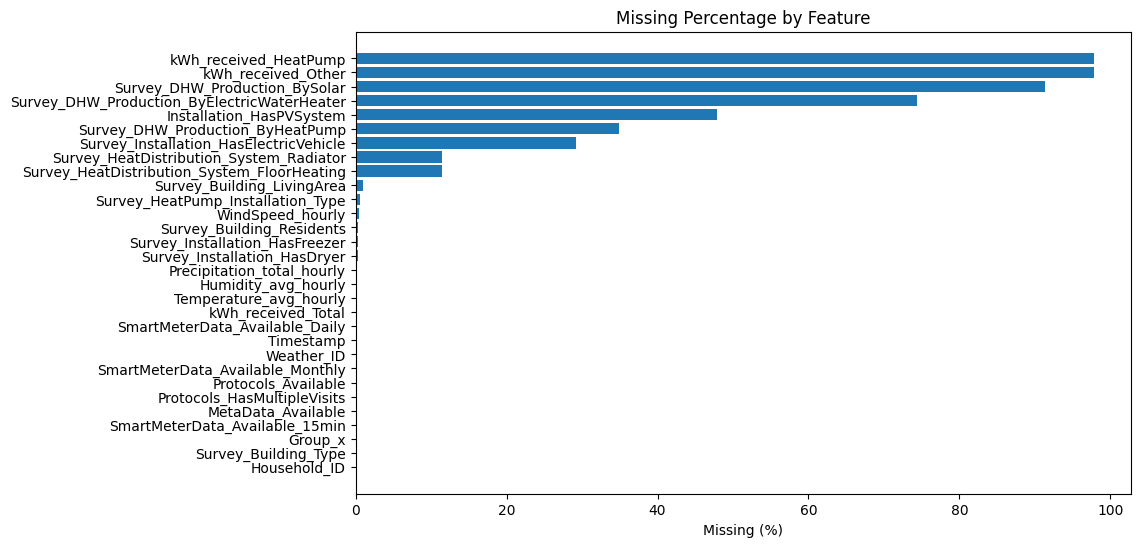

In [24]:
plt.figure(figsize=(10,6))

plt.barh(
    missing_df['feature'],
    missing_df['missing_percent']
)

plt.xlabel('Missing (%)')
plt.title('Missing Percentage by Feature')

plt.gca().invert_yaxis()

plt.show()

In [25]:
missing_df[
    missing_df['missing_percent'] > 0
]

,feature,missing_percent
0,kWh_received_HeatPump,97.825170
1,kWh_received_Other,97.818611
2,Survey_DHW_Production_BySolar,91.348469
3,Survey_DHW_Production_ByElectricWaterHeater,74.393981
4,Installation_HasPVSystem,47.947139
5,Survey_DHW_Production_ByHeatPump,34.831945
6,Survey_Installation_HasElectricVehicle,29.148590
7,Survey_HeatDistribution_System_Radiator,11.371395
8,Survey_HeatDistribution_System_FloorHeating,11.371395
9,Survey_Building_LivingArea,0.947642


In [26]:
master_df[
[
    'Installation_HasPVSystem',
    'Survey_DHW_Production_ByHeatPump',
    'Survey_DHW_Production_ByElectricWaterHeater',
    'Survey_DHW_Production_BySolar',
    'Survey_Installation_HasElectricVehicle',
    'Survey_HeatDistribution_System_Radiator',
    'Survey_HeatDistribution_System_FloorHeating'
]
].describe(include='all')

,Installation_HasPVSystem,Survey_DHW_Production_ByHeatPump,Survey_DHW_Production_ByElectricWaterHeater,Survey_DHW_Production_BySolar,Survey_Installation_HasElectricVehicle,Survey_HeatDistribution_System_Radiator,Survey_HeatDistribution_System_FloorHeating
count,15998784,20029824,7870176,2659104,21776640,27240576,27240576
unique,2,1,1,1,2,2,2
top,False,True,True,True,False,False,True
freq,8827872,20029824,7870176,2659104,13965888,17949888,20788704


In [27]:
for col in [
    'Installation_HasPVSystem',
    'Survey_DHW_Production_ByHeatPump',
    'Survey_DHW_Production_ByElectricWaterHeater',
    'Survey_DHW_Production_BySolar',
    'Survey_Installation_HasElectricVehicle',
    'Survey_HeatDistribution_System_Radiator',
    'Survey_HeatDistribution_System_FloorHeating'
]:
    print('\n', col)
    print(master_df[col].value_counts(dropna=False))


 Installation_HasPVSystem
Installation_HasPVSystem
NaN      14736864
False     8827872
True      7170912
Name: count, dtype: int64

 Survey_DHW_Production_ByHeatPump
Survey_DHW_Production_ByHeatPump
True    20029824
NaN     10705824
Name: count, dtype: int64

 Survey_DHW_Production_ByElectricWaterHeater
Survey_DHW_Production_ByElectricWaterHeater
NaN     22865472
True     7870176
Name: count, dtype: int64

 Survey_DHW_Production_BySolar
Survey_DHW_Production_BySolar
NaN     28076544
True     2659104
Name: count, dtype: int64

 Survey_Installation_HasElectricVehicle
Survey_Installation_HasElectricVehicle
False    13965888
NaN       8959008
True      7810752
Name: count, dtype: int64

 Survey_HeatDistribution_System_Radiator
Survey_HeatDistribution_System_Radiator
False    17949888
True      9290688
NaN       3495072
Name: count, dtype: int64

 Survey_HeatDistribution_System_FloorHeating
Survey_HeatDistribution_System_FloorHeating
True     20788704
False     6451872
NaN       3495072
Na

In [28]:
drop_high_missing = [
    'kWh_received_HeatPump',
    'kWh_received_Other'
]

master_df = master_df.drop(
    columns=drop_high_missing
)

master_df.shape

(30735648, 28)

In [29]:
false_cols = [
    'Installation_HasPVSystem',
    'Survey_DHW_Production_ByHeatPump',
    'Survey_DHW_Production_ByElectricWaterHeater',
    'Survey_DHW_Production_BySolar',
    'Survey_Installation_HasElectricVehicle',
    'Survey_HeatDistribution_System_Radiator',
    'Survey_HeatDistribution_System_FloorHeating'
]

for col in false_cols:

    if False not in master_df[col].cat.categories:
        master_df[col] = (
            master_df[col]
            .cat.add_categories([False])
        )

    master_df[col] = (
        master_df[col]
        .fillna(False)
    )

In [30]:
master_df.isnull().sum().sort_values(
    ascending=False
).head(15)

Survey_Building_LivingArea                291264
Survey_HeatPump_Installation_Type         175200
WindSpeed_hourly                          130788
Survey_Installation_HasFreezer             73728
Survey_Installation_HasDryer               73728
Survey_Building_Residents                  73728
Precipitation_total_hourly                 61492
Humidity_avg_hourly                        25672
Temperature_avg_hourly                     25672
kWh_received_Total                          2208
Protocols_Available                            0
Protocols_HasMultipleVisits                    0
Survey_Installation_HasElectricVehicle         0
Timestamp                                      0
Survey_DHW_Production_BySolar                  0
dtype: int64

In [31]:
master_df[
    false_cols
].isnull().sum()

Installation_HasPVSystem                       0
Survey_DHW_Production_ByHeatPump               0
Survey_DHW_Production_ByElectricWaterHeater    0
Survey_DHW_Production_BySolar                  0
Survey_Installation_HasElectricVehicle         0
Survey_HeatDistribution_System_Radiator        0
Survey_HeatDistribution_System_FloorHeating    0
dtype: int64

In [32]:
weather_cols = [
    'Temperature_avg_hourly',
    'Humidity_avg_hourly',
    'Precipitation_total_hourly',
    'WindSpeed_hourly'
]

for col in weather_cols:
    master_df[col] = (
        master_df[col]
        .fillna(
            master_df[col].median()
        )
    )

In [33]:
master_df.isnull().mean().mul(100).sort_values(
    ascending=False
).head(15)

Survey_Building_LivingArea                     0.947642
Survey_HeatPump_Installation_Type              0.570022
Survey_Building_Residents                      0.239878
Survey_Installation_HasFreezer                 0.239878
Survey_Installation_HasDryer                   0.239878
kWh_received_Total                             0.007184
Precipitation_total_hourly                     0.000000
Humidity_avg_hourly                            0.000000
Temperature_avg_hourly                         0.000000
Survey_Installation_HasElectricVehicle         0.000000
Survey_DHW_Production_BySolar                  0.000000
Survey_DHW_Production_ByElectricWaterHeater    0.000000
Survey_DHW_Production_ByHeatPump               0.000000
Survey_HeatDistribution_System_Radiator        0.000000
Survey_HeatDistribution_System_FloorHeating    0.000000
dtype: float64

In [34]:
master_df['Survey_Building_LivingArea'] = (
    master_df['Survey_Building_LivingArea']
    .fillna(
        master_df['Survey_Building_LivingArea'].median()
    )
)

master_df['Survey_Building_Residents'] = (
    master_df['Survey_Building_Residents']
    .fillna(
        master_df['Survey_Building_Residents'].median()
    )
)

In [35]:
for col in [
    'Survey_Installation_HasDryer',
    'Survey_Installation_HasFreezer'
]:

    if False not in master_df[col].cat.categories:
        master_df[col] = (
            master_df[col]
            .cat.add_categories([False])
        )

    master_df[col] = (
        master_df[col]
        .fillna(False)
    )

In [36]:
mode_value = (
    master_df[
        'Survey_HeatPump_Installation_Type'
    ]
    .mode()[0]
)

master_df[
    'Survey_HeatPump_Installation_Type'
] = (
    master_df[
        'Survey_HeatPump_Installation_Type'
    ]
    .fillna(mode_value)
)

In [37]:
master_df = (
    master_df
    .dropna(
        subset=['kWh_received_Total']
    )
)

In [38]:
master_df.isnull().sum().sort_values(
    ascending=False
).head(10)

Household_ID                                   0
Group_x                                        0
Precipitation_total_hourly                     0
Humidity_avg_hourly                            0
Temperature_avg_hourly                         0
Survey_Installation_HasElectricVehicle         0
Survey_Installation_HasFreezer                 0
Survey_Installation_HasDryer                   0
Survey_DHW_Production_BySolar                  0
Survey_DHW_Production_ByElectricWaterHeater    0
dtype: int64

# Feature Engineering

Temporal Features

In [39]:
master_df.columns.tolist()

['Household_ID',
 'Group_x',
 'Timestamp',
 'kWh_received_Total',
 'Weather_ID',
 'Installation_HasPVSystem',
 'Protocols_Available',
 'Protocols_HasMultipleVisits',
 'MetaData_Available',
 'SmartMeterData_Available_15min',
 'SmartMeterData_Available_Daily',
 'SmartMeterData_Available_Monthly',
 'Survey_Building_Type',
 'Survey_Building_LivingArea',
 'Survey_Building_Residents',
 'Survey_HeatPump_Installation_Type',
 'Survey_HeatDistribution_System_FloorHeating',
 'Survey_HeatDistribution_System_Radiator',
 'Survey_DHW_Production_ByHeatPump',
 'Survey_DHW_Production_ByElectricWaterHeater',
 'Survey_DHW_Production_BySolar',
 'Survey_Installation_HasDryer',
 'Survey_Installation_HasFreezer',
 'Survey_Installation_HasElectricVehicle',
 'Temperature_avg_hourly',
 'Humidity_avg_hourly',
 'Precipitation_total_hourly',
 'WindSpeed_hourly']

In [40]:
master_df['hour'] = (
    master_df['Timestamp']
    .dt.hour
)

master_df['day'] = (
    master_df['Timestamp']
    .dt.day
)

master_df['dayofweek'] = (
    master_df['Timestamp']
    .dt.dayofweek
)

master_df['month'] = (
    master_df['Timestamp']
    .dt.month
)

master_df['quarter'] = (
    master_df['Timestamp']
    .dt.quarter
)

master_df['is_weekend'] = (
    master_df['dayofweek']
    .isin([5, 6])
    .astype('int8')
)

In [41]:
def get_season(month):

    if month in [12,1,2]:
        return 'Winter'

    elif month in [3,4,5]:
        return 'Spring'

    elif month in [6,7,8]:
        return 'Summer'

    else:
        return 'Autumn'


master_df['season'] = (
    master_df['month']
    .apply(get_season)
    .astype('category')
)

In [42]:
small_int_cols = [
    'hour',
    'day',
    'dayofweek',
    'month',
    'quarter',
    'is_weekend'
]

for col in small_int_cols:
    master_df[col] = (
        master_df[col]
        .astype('int8')
    )

In [43]:
master_df[
[
    'Timestamp',
    'hour',
    'day',
    'dayofweek',
    'month',
    'quarter',
    'season',
    'is_weekend'
]
].head()

,Timestamp,hour,day,dayofweek,month,quarter,season,is_weekend
0,2021-01-17 00:00:00+00:00,0,17,6,1,1,Winter,1
1,2021-01-17 00:15:00+00:00,0,17,6,1,1,Winter,1
2,2021-01-17 00:30:00+00:00,0,17,6,1,1,Winter,1
3,2021-01-17 00:45:00+00:00,0,17,6,1,1,Winter,1
4,2021-01-17 01:00:00+00:00,1,17,6,1,1,Winter,1


In [44]:
master_df[
[
    'hour',
    'dayofweek',
    'month',
    'season',
    'is_weekend'
]
].describe(include='all')

,hour,dayofweek,month,season,is_weekend
count,3.073344e+07,3.073344e+07,3.073344e+07,30733440,3.073344e+07
unique,NaN,NaN,NaN,4,NaN
top,NaN,NaN,NaN,Winter,NaN
freq,NaN,NaN,NaN,8721792,NaN
mean,1.150000e+01,2.993319e+00,6.515859e+00,NaN,2.845255e-01
std,6.922187e+00,1.998701e+00,3.570762e+00,NaN,4.511882e-01
min,0.000000e+00,0.000000e+00,1.000000e+00,NaN,0.000000e+00
25%,5.750000e+00,1.000000e+00,3.000000e+00,NaN,0.000000e+00
50%,1.150000e+01,3.000000e+00,7.000000e+00,NaN,0.000000e+00
75%,1.725000e+01,5.000000e+00,1.000000e+01,NaN,1.000000e+00


In [45]:
master_df.shape

(30733440, 35)

Cyclical Encoding

In [46]:
import numpy as np

master_df['hour_sin'] = np.sin(
    2 * np.pi * master_df['hour'] / 24
)

master_df['hour_cos'] = np.cos(
    2 * np.pi * master_df['hour'] / 24
)

master_df['month_sin'] = np.sin(
    2 * np.pi * master_df['month'] / 12
)

master_df['month_cos'] = np.cos(
    2 * np.pi * master_df['month'] / 12
)

In [47]:
cyclic_cols = [
    'hour_sin',
    'hour_cos',
    'month_sin',
    'month_cos'
]

master_df[cyclic_cols] = (
    master_df[cyclic_cols]
    .astype('float32')
)

In [48]:
master_df[
[
    'hour',
    'hour_sin',
    'hour_cos',
    'month',
    'month_sin',
    'month_cos'
]
].head(30)

,hour,hour_sin,hour_cos,month,month_sin,month_cos
0,0,0.000000,1.000000e+00,1,0.5,0.866025
1,0,0.000000,1.000000e+00,1,0.5,0.866025
2,0,0.000000,1.000000e+00,1,0.5,0.866025
3,0,0.000000,1.000000e+00,1,0.5,0.866025
4,1,0.258819,9.659258e-01,1,0.5,0.866025
5,1,0.258819,9.659258e-01,1,0.5,0.866025
6,1,0.258819,9.659258e-01,1,0.5,0.866025
7,1,0.258819,9.659258e-01,1,0.5,0.866025
8,2,0.500000,8.660254e-01,1,0.5,0.866025
9,2,0.500000,8.660254e-01,1,0.5,0.866025


In [49]:
master_df[
[
    'hour_sin',
    'hour_cos',
    'month_sin',
    'month_cos'
]
].describe()

,hour_sin,hour_cos,month_sin,month_cos
count,3.073344e+07,3.073344e+07,3.073344e+07,3.073344e+07
mean,1.241220e-13,-4.966309e-09,3.725346e-04,5.118525e-02
std,7.071068e-01,7.071068e-01,6.985289e-01,7.137488e-01
min,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00
25%,-7.071068e-01,-7.071068e-01,-5.000000e-01,-5.000000e-01
50%,6.123234e-17,-6.123234e-17,-2.449294e-16,6.123234e-17
75%,7.071068e-01,7.071068e-01,5.000000e-01,8.660254e-01
max,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


In [50]:
master_df.shape

(30733440, 39)

# LAG FEATURES

In [51]:
master_df = master_df.sort_values(
    ['Household_ID', 'Timestamp']
).reset_index(drop=True)

In [52]:
master_df['lag_1'] = (
    master_df
    .groupby('Household_ID')['kWh_received_Total']
    .shift(1)
)

In [53]:
master_df['lag_4'] = (
    master_df
    .groupby('Household_ID')['kWh_received_Total']
    .shift(4)
)

In [54]:
master_df['lag_96'] = (
    master_df
    .groupby('Household_ID')['kWh_received_Total']
    .shift(96)
)

In [55]:
master_df['lag_672'] = (
    master_df
    .groupby('Household_ID')['kWh_received_Total']
    .shift(672)
)

In [56]:
lag_cols = [
    'lag_1',
    'lag_4',
    'lag_96',
    'lag_672'
]

master_df[lag_cols] = (
    master_df[lag_cols]
    .astype('float32')
)

In [57]:
master_df[
    lag_cols
].isnull().mean().mul(100)

lag_1      0.000976
lag_4      0.003905
lag_96     0.093709
lag_672    0.655963
dtype: float64

In [58]:
master_df[
[
    'Household_ID',
    'Timestamp',
    'kWh_received_Total',
    'lag_1',
    'lag_4',
    'lag_96',
    'lag_672'
]
].head(120)

,Household_ID,Timestamp,kWh_received_Total,lag_1,lag_4,lag_96,lag_672
0,10266,2021-01-17 00:00:00+00:00,0.000,NaN,NaN,NaN,NaN
1,10266,2021-01-17 00:15:00+00:00,0.000,0.000,NaN,NaN,NaN
2,10266,2021-01-17 00:30:00+00:00,0.000,0.000,NaN,NaN,NaN
3,10266,2021-01-17 00:45:00+00:00,0.000,0.000,NaN,NaN,NaN
4,10266,2021-01-17 01:00:00+00:00,0.000,0.000,0.000,NaN,NaN
...,...,...,...,...,...,...,...
115,10266,2021-01-18 04:45:00+00:00,0.338,0.483,0.299,0.0,NaN
116,10266,2021-01-18 05:00:00+00:00,0.273,0.338,0.330,0.0,NaN
117,10266,2021-01-18 05:15:00+00:00,0.273,0.273,0.353,0.0,NaN
118,10266,2021-01-18 05:30:00+00:00,0.286,0.273,0.483,0.0,NaN


# Rolling Statistics

In [59]:
master_df['rolling_mean_1h'] = (
    master_df
    .groupby('Household_ID')['kWh_received_Total']
    .transform(
        lambda x:
        x.shift(1)
         .rolling(4, min_periods=1)
         .mean()
    )
)

In [60]:
master_df['rolling_std_1h'] = (
    master_df
    .groupby('Household_ID')['kWh_received_Total']
    .transform(
        lambda x:
        x.shift(1)
         .rolling(4, min_periods=1)
         .std()
    )
)

In [61]:
master_df['rolling_mean_24h'] = (
    master_df
    .groupby('Household_ID')['kWh_received_Total']
    .transform(
        lambda x:
        x.shift(1)
         .rolling(96, min_periods=1)
         .mean()
    )
)

In [62]:
master_df['rolling_std_24h'] = (
    master_df
    .groupby('Household_ID')['kWh_received_Total']
    .transform(
        lambda x:
        x.shift(1)
         .rolling(96, min_periods=1)
         .std()
    )
)

In [63]:
rolling_cols = [
    'rolling_mean_1h',
    'rolling_std_1h',
    'rolling_mean_24h',
    'rolling_std_24h'
]

master_df[rolling_cols] = (
    master_df[rolling_cols]
    .astype('float32')
)

In [64]:
master_df[
    rolling_cols
].isnull().mean().mul(100)

rolling_mean_1h     0.000976
rolling_std_1h      0.001952
rolling_mean_24h    0.000976
rolling_std_24h     0.001952
dtype: float64

In [65]:
master_df[
[
    'Household_ID',
    'Timestamp',
    'kWh_received_Total',
    'rolling_mean_1h',
    'rolling_std_1h',
    'rolling_mean_24h',
    'rolling_std_24h'
]
].head(120)

,Household_ID,Timestamp,kWh_received_Total,rolling_mean_1h,rolling_std_1h,rolling_mean_24h,rolling_std_24h
0,10266,2021-01-17 00:00:00+00:00,0.000,NaN,NaN,NaN,NaN
1,10266,2021-01-17 00:15:00+00:00,0.000,0.00000,NaN,0.000000,NaN
2,10266,2021-01-17 00:30:00+00:00,0.000,0.00000,0.000000,0.000000,0.000000
3,10266,2021-01-17 00:45:00+00:00,0.000,0.00000,0.000000,0.000000,0.000000
4,10266,2021-01-17 01:00:00+00:00,0.000,0.00000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...
115,10266,2021-01-18 04:45:00+00:00,0.338,0.36625,0.080917,0.078583,0.149149
116,10266,2021-01-18 05:00:00+00:00,0.273,0.37600,0.071968,0.082104,0.151249
117,10266,2021-01-18 05:15:00+00:00,0.273,0.36175,0.087975,0.084948,0.152252
118,10266,2021-01-18 05:30:00+00:00,0.286,0.34175,0.099027,0.087792,0.153195


# Encoding Categorical Variables

In [66]:
master_df.select_dtypes(
    include=['category','object']
).columns.tolist()

['Group_x',
 'Weather_ID',
 'Installation_HasPVSystem',
 'Survey_Building_Type',
 'Survey_HeatPump_Installation_Type',
 'Survey_HeatDistribution_System_FloorHeating',
 'Survey_HeatDistribution_System_Radiator',
 'Survey_DHW_Production_ByHeatPump',
 'Survey_DHW_Production_ByElectricWaterHeater',
 'Survey_DHW_Production_BySolar',
 'Survey_Installation_HasDryer',
 'Survey_Installation_HasFreezer',
 'Survey_Installation_HasElectricVehicle',
 'season']

In [67]:
categorical_cols = [
    'Survey_Building_Type',
    'Survey_HeatPump_Installation_Type',
    'season'
]

master_df = master_df.drop(columns=['Weather_ID'])

master_df = pd.get_dummies(
    master_df,
    columns=categorical_cols,
    drop_first=True,
    dtype='int8'
)

In [68]:
master_df[
[
    'lag_1',
    'lag_4',
    'lag_96',
    'lag_672',
    'rolling_mean_1h',
    'rolling_std_1h',
    'rolling_mean_24h',
    'rolling_std_24h'
]
].isnull().sum()

lag_1                  300
lag_4                 1200
lag_96               28800
lag_672             201600
rolling_mean_1h        300
rolling_std_1h         600
rolling_mean_24h       300
rolling_std_24h        600
dtype: int64

In [69]:
lag_fill_cols = [
    'lag_1',
    'lag_4',
    'lag_96',
    'lag_672',
    'rolling_mean_1h',
    'rolling_std_1h',
    'rolling_mean_24h',
    'rolling_std_24h'
]

master_df[lag_fill_cols] = (
    master_df[lag_fill_cols]
    .fillna(0)
)

In [70]:
master_df.isnull().sum().sort_values(
    ascending=False
).head(20)

Household_ID                  0
Group_x                       0
day                           0
dayofweek                     0
month                         0
quarter                       0
is_weekend                    0
hour_sin                      0
hour_cos                      0
month_sin                     0
month_cos                     0
lag_1                         0
lag_4                         0
lag_96                        0
lag_672                       0
rolling_mean_1h               0
rolling_std_1h                0
rolling_mean_24h              0
rolling_std_24h               0
Survey_Building_Type_house    0
dtype: int64

In [71]:
DROP_METADATA = [
    "Group_x",
    "MetaData_Available",
    "Protocols_Available",
    "Protocols_HasMultipleVisits",
    "SmartMeterData_Available_15min",
    "SmartMeterData_Available_Daily",
    "SmartMeterData_Available_Monthly"
]

master_df = master_df.drop(columns=DROP_METADATA, errors="ignore")

# Pembagian Data (Train / Valid / Test)

In [72]:
master_df['Timestamp'].min()
master_df['Timestamp'].max()

Timestamp('2024-02-27 23:45:00+0000', tz='UTC')

In [73]:
train_df = master_df[
    master_df['Timestamp'] < '2023-01-01'
].copy()

valid_df = master_df[
    (master_df['Timestamp'] >= '2023-01-01') &
    (master_df['Timestamp'] < '2024-01-01')
].copy()

test_df = master_df[
    master_df['Timestamp'] >= '2024-01-01'
].copy()

In [74]:
print(train_df.shape)
print(valid_df.shape)
print(test_df.shape)

(19127904, 41)
(9976416, 41)
(1629120, 41)


In [75]:
total = len(master_df)

print(
    f"Train : {len(train_df)/total:.2%}"
)
print(
    f"Valid : {len(valid_df)/total:.2%}"
)
print(
    f"Test : {len(test_df)/total:.2%}"
)

Train : 62.24%
Valid : 32.46%
Test : 5.30%


In [76]:
TARGET = 'kWh_received_Total'

DROP_COLUMNS = [
    TARGET,
    'Timestamp',
    'Household_ID'
]

X_train = train_df.drop(columns=DROP_COLUMNS)
y_train = train_df[TARGET]

X_valid = valid_df.drop(columns=DROP_COLUMNS)
y_valid = valid_df[TARGET]

X_test = test_df.drop(columns=DROP_COLUMNS)
y_test = test_df[TARGET]

In [77]:
train_df.to_parquet(
    PROCESSED_DIR /
    'train_dataset.parquet'
)

valid_df.to_parquet(
    PROCESSED_DIR /
    'valid_dataset.parquet'
)

test_df.to_parquet(
    PROCESSED_DIR /
    'test_dataset.parquet'
)

In [78]:
train_df.to_parquet(
    PROCESSED_DIR / "train_final.parquet"
)

valid_df.to_parquet(
    PROCESSED_DIR / "valid_final.parquet"
)

test_df.to_parquet(
    PROCESSED_DIR / "test_final.parquet"
)

In [79]:
X_train.to_parquet(
    PROCESSED_DIR / "X_train.parquet"
)
X_valid.to_parquet(
    PROCESSED_DIR / "X_valid.parquet"
)
X_test.to_parquet(
    PROCESSED_DIR / "X_test.parquet"
)

In [80]:
y_train.to_frame().to_parquet(
    PROCESSED_DIR / "y_train.parquet"
)
y_valid.to_frame().to_parquet(
    PROCESSED_DIR / "y_valid.parquet"
)
y_test.to_frame().to_parquet(
    PROCESSED_DIR / "y_test.parquet"
)

In [81]:
print("Jumlah fitur:", len(X_train.columns))

print("\nApakah Household_ID masih ada?")
print("Household_ID" in X_train.columns)

print("\nApakah Timestamp masih ada?")
print("Timestamp" in X_train.columns)

Jumlah fitur: 38

Apakah Household_ID masih ada?
False

Apakah Timestamp masih ada?
False


Tahap **Preprocessing dan Feature Engineering** berhasil mentransformasikan data mentah yang berasal dari berbagai sumber, yaitu data smart meter, metadata rumah tangga, dan data cuaca, menjadi suatu dataset terintegrasi yang siap digunakan dalam proses pemodelan prediktif. Proses ini mencakup optimasi tipe data yang secara signifikan menurunkan kebutuhan memori dari sekitar **14,38 GB menjadi 2,29 GB**, atau berkurang sebesar **84,11%**, sehingga meningkatkan efisiensi komputasi pada tahap pemodelan selanjutnya. Penanganan data hilang dilakukan secara sistematis melalui penghapusan variabel dengan tingkat kehilangan data yang sangat tinggi dan tidak representatif, serta penerapan strategi imputasi yang disesuaikan dengan karakteristik masing-masing variabel. Hasilnya, dataset akhir tidak lagi mengandung missing value.

Selain proses pembersihan data, dilakukan pula serangkaian rekayasa fitur (*feature engineering*) untuk meningkatkan kemampuan model dalam menangkap pola konsumsi listrik. Fitur temporal, seperti jam, hari, bulan, kuartal, musim, dan indikator akhir pekan, dibentuk untuk merepresentasikan pola periodik konsumsi energi. Selanjutnya, penerapan *cyclical encoding* memungkinkan model memahami sifat siklus waktu, seperti kedekatan antara pukul 23.00 dan 00.00 atau antara bulan Desember dan Januari. Untuk menangkap ketergantungan temporal, dibangun pula *lag features* dan *rolling statistics* yang merepresentasikan pengaruh konsumsi historis, baik dalam jangka pendek maupun jangka panjang, serta dinamika rata-rata dan variabilitas konsumsi sebelumnya.

Tahap encoding juga telah mengonversi seluruh variabel kategorikal ke dalam bentuk numerik sehingga kompatibel dengan berbagai algoritma *machine learning*. Dataset akhir terdiri atas **30.733.440 observasi dan 55 fitur**, bebas dari nilai hilang, efisien secara memori, dan telah dibagi menggunakan pendekatan **time-based split** untuk mencegah terjadinya *data leakage*. Dengan demikian, dataset yang dihasilkan memiliki kualitas yang tinggi, mampu merepresentasikan karakteristik temporal dan kontekstual konsumsi listrik secara komprehensif, serta berada dalam kondisi yang optimal untuk digunakan pada tahap pemodelan dan evaluasi guna menghasilkan model prediksi konsumsi listrik yang akurat, robust, dan dapat dipertanggungjawabkan secara ilmiah.
